#**Analisis Dampak Penggunaan AI Generatif terhadap Performa Akademik dan Kesejahteraan Mahasiswa**

#**A. Latar Belakang Bisnis**

Perkembangan teknologi Artificial Intelligence (AI) generatif seperti ChatGPT, Gemini, dan Copilot telah mengubah cara mahasiswa belajar, mencari informasi, dan menyelesaikan tugas akademik. Meskipun penggunaan AI menawarkan berbagai manfaat dalam meningkatkan efisiensi belajar, terdapat kekhawatiran terkait dampaknya terhadap performa akademik, retensi pengetahuan, kesehatan mental, serta tingkat ketergantungan mahasiswa terhadap teknologi tersebut.

Sebagai perusahaan konsultan di bidang pendidikan tinggi internasional, diperlukan analisis berbasis data untuk memahami hubungan antara penggunaan AI generatif dengan capaian akademik dan kesejahteraan mahasiswa. Hasil analisis ini diharapkan dapat menjadi dasar dalam penyusunan kebijakan penggunaan AI yang efektif, bertanggung jawab, dan berbasis bukti (evidence-based policy) di lingkungan perguruan tinggi.

#**B. Tujuan Analisis**

Analisis ini dilakukan untuk:

1. Mengidentifikasi pengaruh penggunaan AI generatif terhadap performa akademik mahasiswa.
2. Menganalisis hubungan antara tingkat ketergantungan AI dengan retensi pengetahuan mahasiswa.
3. Mengevaluasi dampak kebijakan institusi terhadap performa akademik dan kesehatan mental mahasiswa.
4. Mengidentifikasi profil mahasiswa yang memiliki risiko burnout tinggi.
5. Menyusun rekomendasi kebijakan penggunaan AI berdasarkan hasil analisis data.

#**C. Data Preparation**

##**Import Library**

In [ ]:
# Import library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Library berhasil diimport")

Library berhasil diimport


##**Import Dataset**

In [ ]:
# Memuat dataset dari Google Spreadsheet

dataset_url = 'https://docs.google.com/spreadsheets/d/11iF9-jtxtpS3qO_OV8MCPphXRnc50djrZhwtb3kEvIQ/export?format=csv&gid=1248323714'

df = pd.read_csv(dataset_url)

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1.0,True,8.13,5.0,Allowed_With_Citation,6.0,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5.0,False,16.65,3.0,Allowed_With_Citation,9.0,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2.0,False,10.35,5.0,Strict_Ban,9.0,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4.0,False,15.23,2.0,Allowed_With_Citation,2.0,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4.0,False,12.55,4.0,Allowed_With_Citation,4.0,3.798,100.00,Medium


In [ ]:
# Menampilkan dimensi dataset

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 50000
Jumlah kolom : 16


In [ ]:
# Menampilkan informasi dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  object 
 1   Major_Category              49998 non-null  object 
 2   Year_of_Study               49998 non-null  object 
 3   Pre_Semester_GPA            49998 non-null  float64
 4   Weekly_GenAI_Hours          49998 non-null  float64
 5   Primary_Use_Case            49998 non-null  object 
 6   Prompt_Engineering_Skill    49998 non-null  object 
 7   Tool_Diversity              49998 non-null  float64
 8   Paid_Subscription           49998 non-null  object 
 9   Traditional_Study_Hours     49998 non-null  float64
 10  Perceived_AI_Dependency     49998 non-null  float64
 11  Institutional_Policy        49998 non-null  object 
 12  Anxiety_Level_During_Exams  49998 non-null  float64
 13  Post_Semester_GPA           499

In [ ]:
# Menampilkan daftar kolom

df.columns.tolist()

['Student_ID',
 'Major_Category',
 'Year_of_Study',
 'Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Tool_Diversity',
 'Paid_Subscription',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Institutional_Policy',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'Burnout_Risk_Level']

In [ ]:
# Menampilkan 5 baris pertama dataset

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1.0,True,8.13,5.0,Allowed_With_Citation,6.0,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5.0,False,16.65,3.0,Allowed_With_Citation,9.0,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2.0,False,10.35,5.0,Strict_Ban,9.0,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4.0,False,15.23,2.0,Allowed_With_Citation,2.0,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4.0,False,12.55,4.0,Allowed_With_Citation,4.0,3.798,100.00,Medium


#**D. Data Cleaning**

##**Check Missing Values**

In [ ]:
# Memeriksa missing values

missing_values = df.isnull().sum()

missing_values

,0
Student_ID,0
Major_Category,2
Year_of_Study,2
Pre_Semester_GPA,2
Weekly_GenAI_Hours,2
Primary_Use_Case,2
Prompt_Engineering_Skill,2
Tool_Diversity,2
Paid_Subscription,2
Traditional_Study_Hours,2


In [ ]:
# Menampilkan baris yang memiliki missing values

df[df.isnull().any(axis=1)]

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
464,"100465,Medical,Junior,2.388,7.65,"" "",Advanced,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45824,"145825,Business,Junior,3.592,1.98,Ideation,Beg...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Menampilkan isi lengkap record yang bermasalah

for value in df[df.isnull().any(axis=1)]['Student_ID']:
    print(repr(value))
    print()

'100465,Medical,Junior,2.388,7.65," ",Advanced,4,True,7.48,4,Actively_Encouraged,1,2.568,88.47,High'

'145825,Business,Junior,3.592,1.98,Ideation,Beginner,1,False,16.46,3,Allowed_With_Citation,1," ",70.29,Medium'



In [ ]:
# Membuat salinan dataset untuk proses cleaning
df_clean = df.copy()

# Menghapus record yang mengandung missing values
df_clean = df_clean.dropna()

In [ ]:
# Menampilkan informasi dataset setelah pembersihan missing values

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49998 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  49998 non-null  object 
 1   Major_Category              49998 non-null  object 
 2   Year_of_Study               49998 non-null  object 
 3   Pre_Semester_GPA            49998 non-null  float64
 4   Weekly_GenAI_Hours          49998 non-null  float64
 5   Primary_Use_Case            49998 non-null  object 
 6   Prompt_Engineering_Skill    49998 non-null  object 
 7   Tool_Diversity              49998 non-null  float64
 8   Paid_Subscription           49998 non-null  object 
 9   Traditional_Study_Hours     49998 non-null  float64
 10  Perceived_AI_Dependency     49998 non-null  float64
 11  Institutional_Policy        49998 non-null  object 
 12  Anxiety_Level_During_Exams  49998 non-null  float64
 13  Post_Semester_GPA           49998 no

**Hasil Pemeriksaan Missing Values**:

Ditemukan 2 record yang mengalami kesalahan struktur data (parsing error) sehingga menghasilkan missing values pada sebagian besar kolom. Karena jumlahnya sangat kecil (0,004% dari total data) dan tidak dapat digunakan secara optimal dalam analisis, kedua record tersebut dihapus dari dataset.

Jumlah data sebelum pembersihan : 50.000 record

Jumlah data sesudah pembersihan : 49.998 record

##**Check Duplicates**

In [ ]:
# Memeriksa jumlah data duplikat

duplicate_count = df_clean.duplicated().sum()

print("Jumlah data duplikat :", duplicate_count)

Jumlah data duplikat : 0


##**Check Invalid Value**

###**a. Year_of_Study**

In [ ]:
# Menampilkan nilai unik pada Year_of_Study

df_clean['Year_of_Study'].unique()

array(['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate', '123'],
      dtype=object)

In [ ]:
# Menghitung jumlah nilai Year_of_Study yang tidak valid

invalid_year = df_clean[df_clean['Year_of_Study'] == '123']

print("Jumlah record tidak valid :", len(invalid_year))

Jumlah record tidak valid : 1


In [ ]:
# Menampilkan record yang tidak valid

invalid_year.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
27686,127687,Business,123,3.514,28.5,Summarizing_Reading,Beginner,3.0,False,8.89,5.0,Actively_Encouraged,4.0,3.629,63.62,Medium


In [ ]:
# Menghapus nilai Year_of_Study yang tidak valid

df_clean = df_clean[df_clean['Year_of_Study'] != '123']

print("Jumlah data setelah penghapusan :", len(df_clean))

Jumlah data setelah penghapusan : 49997


**Hasil Validasi Year_of_Study**:

Ditemukan 1 record dengan nilai Year_of_Study = "123" yang tidak sesuai dengan kategori yang didefinisikan dalam data dictionary (Freshman, Sophomore, Junior, Senior, Graduate).

Karena tidak tersedia informasi yang dapat digunakan untuk menentukan kategori yang benar, record tersebut dihapus dari dataset.

###**b. Post_Semester_GPA**

In [ ]:
# Memeriksa rentang nilai Post_Semester_GPA

df_clean['Post_Semester_GPA'].describe()

,Post_Semester_GPA
count,49997.000000
mean,3.349441
std,0.496669
min,1.000000
25%,3.024000
50%,3.421000
75%,3.749000
max,10.389000


In [ ]:
# Menghitung jumlah GPA yang melebihi batas valid

invalid_gpa = df_clean[df_clean['Post_Semester_GPA'] > 4]

print("Jumlah GPA tidak valid :", len(invalid_gpa))

Jumlah GPA tidak valid : 1


In [ ]:
# Menampilkan record dengan GPA tidak valid

invalid_gpa.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
88,100089,Medical,Graduate,3.367,6.51,Summarizing_Reading,Beginner,3.0,True,2.53,1.0,Actively_Encouraged,2.0,10.389,79.27,High


In [ ]:
# Menghapus nilai GPA yang tidak valid

df_clean = df_clean[df_clean['Post_Semester_GPA'] <= 4]

print("Jumlah data setelah validasi GPA :", len(df_clean))

Jumlah data setelah validasi GPA : 49996


**Hasil Validasi Post_Semester_GPA**:

Ditemukan 1 record dengan nilai Post_Semester_GPA sebesar 10.389. Nilai tersebut berada di luar rentang valid GPA (1.00–4.00) sehingga dikategorikan sebagai invalid value.

Karena nilai sebenarnya tidak dapat diketahui dan tidak memungkinkan dilakukan koreksi secara akurat, record tersebut dihapus dari dataset.

###**c. Tool_Diversity**

In [ ]:
# Menampilkan statistik Tool_Diversity

df_clean['Tool_Diversity'].describe()

,Tool_Diversity
count,49996.000000
mean,2.800524
std,1.189930
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,18.000000


In [ ]:
# Menghitung jumlah Tool_Diversity yang tidak valid

invalid_tool = df_clean[df_clean['Tool_Diversity'] > 5]

print("Jumlah Tool_Diversity tidak valid :", len(invalid_tool))

Jumlah Tool_Diversity tidak valid : 1


In [ ]:
# Menampilkan record dengan Tool_Diversity tidak valid

invalid_tool.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
296,100297,Arts,Junior,3.393,10.72,Summarizing_Reading,Advanced,18.0,True,13.07,5.0,Allowed_With_Citation,7.0,3.695,71.89,Medium


In [ ]:
# Menghapus Tool_Diversity yang tidak valid

df_clean = df_clean[df_clean['Tool_Diversity'] <= 5]

print("Jumlah data setelah validasi Tool_Diversity :", len(df_clean))

Jumlah data setelah validasi Tool_Diversity : 49995


**Hasil Validasi Tool_Diversity**:

Ditemukan 1 record dengan nilai Tool_Diversity sebesar 18, sementara rentang nilai yang valid berdasarkan data dictionary adalah 1–5.

Karena nilai tersebut tidak sesuai dengan aturan bisnis dan tidak dapat dikoreksi secara akurat, record tersebut dihapus dari dataset.

In [ ]:
# Memeriksa tipe data setelah proses cleaning

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49995 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  49995 non-null  object 
 1   Major_Category              49995 non-null  object 
 2   Year_of_Study               49995 non-null  object 
 3   Pre_Semester_GPA            49995 non-null  float64
 4   Weekly_GenAI_Hours          49995 non-null  float64
 5   Primary_Use_Case            49995 non-null  object 
 6   Prompt_Engineering_Skill    49995 non-null  object 
 7   Tool_Diversity              49995 non-null  float64
 8   Paid_Subscription           49995 non-null  object 
 9   Traditional_Study_Hours     49995 non-null  float64
 10  Perceived_AI_Dependency     49995 non-null  float64
 11  Institutional_Policy        49995 non-null  object 
 12  Anxiety_Level_During_Exams  49995 non-null  float64
 13  Post_Semester_GPA           49995 no

###**d. Pre_Semester_GPA**

In [ ]:
# Memeriksa statistik Pre_Semester_GPA

df_clean['Pre_Semester_GPA'].describe()

,Pre_Semester_GPA
count,49995.000000
mean,3.146272
std,0.480584
min,1.183000
25%,2.834000
50%,3.210000
75%,3.521000
max,12.249000


In [ ]:
# Menghitung jumlah Pre_Semester_GPA yang tidak valid

invalid_pre_gpa = df_clean[
    (df_clean['Pre_Semester_GPA'] < 1) |
    (df_clean['Pre_Semester_GPA'] > 4)
]

print("Jumlah Pre_Semester_GPA tidak valid :", len(invalid_pre_gpa))

Jumlah Pre_Semester_GPA tidak valid : 1


In [ ]:
# Menampilkan record dengan Pre_Semester_GPA tidak valid

invalid_pre_gpa.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
45218,145219,Humanities,Graduate,12.249,14.51,Ideation,Beginner,2.0,False,7.58,5.0,Strict_Ban,9.0,3.293,88.74,High


In [ ]:
# Menghapus nilai Pre_Semester_GPA yang tidak valid

df_clean = df_clean[
    (df_clean['Pre_Semester_GPA'] >= 1) &
    (df_clean['Pre_Semester_GPA'] <= 4)
]

print("Jumlah data setelah validasi Pre_Semester_GPA :", len(df_clean))

Jumlah data setelah validasi Pre_Semester_GPA : 49994


In [ ]:
# Memastikan tidak ada lagi nilai Year_of_Study yang tidak valid
df_clean['Year_of_Study'].unique()

# Memastikan tidak ada lagi GPA di luar rentang
df_clean['Pre_Semester_GPA'].describe()
df_clean['Post_Semester_GPA'].describe()

# Memastikan Tool_Diversity sudah valid
df_clean['Tool_Diversity'].describe()

# Memastikan tidak ada missing value
df_clean.isnull().sum()

,0
Student_ID,0
Major_Category,0
Year_of_Study,0
Pre_Semester_GPA,0
Weekly_GenAI_Hours,0
Primary_Use_Case,0
Prompt_Engineering_Skill,0
Tool_Diversity,0
Paid_Subscription,0
Traditional_Study_Hours,0


**Hasil Validasi Pre_Semester_GPA**:

Berdasarkan hasil pemeriksaan, ditemukan 1 record dengan nilai **Pre_Semester_GPA sebesar 12.249**, sedangkan rentang nilai GPA yang valid adalah **1.00–4.00**.

Nilai tersebut dikategorikan sebagai **invalid value** karena berada di luar aturan bisnis (business rule). Mengingat nilai sebenarnya tidak dapat diketahui dan hanya ditemukan pada 1 record (0,002% dari total data), record tersebut dihapus dari dataset agar tidak memengaruhi hasil analisis.

##**Check Data Type**

In [ ]:
# Menampilkan contoh data Student_ID

df_clean['Student_ID'].head()

,Student_ID
0,100001
1,100002
2,100003
3,100004
4,100005


In [ ]:
# Memeriksa tipe data setiap nilai pada Student_ID

df_clean['Student_ID'].apply(type).value_counts()

,count
Student_ID,
<class 'str'>,49994


In [ ]:
# Menampilkan nilai unik pada Paid_Subscription

df_clean['Paid_Subscription'].unique()

array([True, False], dtype=object)

**Hasil Validasi Tipe Data**:

Pemeriksaan tipe data menunjukkan bahwa kolom **Student_ID** masih bertipe *object* meskipun seluruh nilainya berupa angka. Selain itu, kolom **Paid_Subscription** juga masih bertipe *object* meskipun hanya memiliki dua nilai, yaitu **True** dan **False**.

Oleh karena itu, dilakukan konversi tipe data agar sesuai dengan karakteristik masing-masing kolom dan mempermudah proses analisis.

In [ ]:
# Mengubah tipe data Student_ID menjadi integer

df_clean['Student_ID'] = df_clean['Student_ID'].astype(int)

In [ ]:
# Mengubah tipe data Paid_Subscription menjadi boolean

df_clean['Paid_Subscription'] = df_clean['Paid_Subscription'].astype(bool)

In [ ]:
# Memeriksa tipe data setelah konversi

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49994 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  49994 non-null  int64  
 1   Major_Category              49994 non-null  object 
 2   Year_of_Study               49994 non-null  object 
 3   Pre_Semester_GPA            49994 non-null  float64
 4   Weekly_GenAI_Hours          49994 non-null  float64
 5   Primary_Use_Case            49994 non-null  object 
 6   Prompt_Engineering_Skill    49994 non-null  object 
 7   Tool_Diversity              49994 non-null  float64
 8   Paid_Subscription           49994 non-null  bool   
 9   Traditional_Study_Hours     49994 non-null  float64
 10  Perceived_AI_Dependency     49994 non-null  float64
 11  Institutional_Policy        49994 non-null  object 
 12  Anxiety_Level_During_Exams  49994 non-null  float64
 13  Post_Semester_GPA           49994 no

**Hasil Konversi Tipe Data**:

Konversi tipe data berhasil dilakukan. Kolom **Student_ID** telah berubah dari *object* menjadi **integer (int64)**, sedangkan kolom **Paid_Subscription** telah berubah dari *object* menjadi **boolean (bool)**.

Perubahan ini membuat struktur data lebih sesuai dengan karakteristik masing-masing variabel, meningkatkan efisiensi penyimpanan data, serta mendukung proses analisis dan visualisasi pada tahap selanjutnya.

**Rangkuman Data Cleaning**

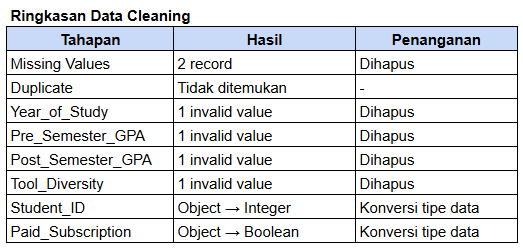

#**E. Exploratory Data Analysis**

##**a. Statistik Deskriptif**

Statistik deskriptif digunakan untuk memberikan gambaran umum mengenai karakteristik variabel numerik, seperti nilai rata-rata (mean), median, standar deviasi, nilai minimum, kuartil (Q1 dan Q3), serta nilai maksimum.

In [ ]:
# Menampilkan statistik deskriptif seluruh variabel numerik

df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Student_ID,49994.0,125001.108493,14432.908442,100001.000,112502.25000,125000.500,137499.7500,150000.000
Pre_Semester_GPA,49994.0,3.146090,0.478862,1.183,2.83400,3.210,3.5210,3.998
Weekly_GenAI_Hours,49994.0,8.427366,8.269392,0.000,2.39000,5.800,11.7200,40.000
Tool_Diversity,49994.0,2.800236,1.188005,1.000,2.00000,3.000,4.0000,5.000
Traditional_Study_Hours,49994.0,11.209496,5.156466,1.000,7.56000,11.180,14.7100,35.860
Perceived_AI_Dependency,49994.0,3.505321,1.820848,1.000,2.00000,3.000,5.0000,10.000
Anxiety_Level_During_Exams,49994.0,4.270792,2.143932,1.000,3.00000,4.000,6.0000,10.000
Post_Semester_GPA,49994.0,3.349295,0.495682,1.000,3.02325,3.421,3.7490,4.000
Skill_Retention_Score,49994.0,75.797975,13.282021,10.780,66.82000,76.000,85.1875,100.000


**Kesimpulan Statistik Deskriptif**:

Berdasarkan statistik deskriptif, rata-rata **Pre_Semester_GPA** sebesar **3,15**, sedangkan rata-rata **Post_Semester_GPA** meningkat menjadi **3,35**. Hal ini menunjukkan adanya peningkatan performa akademik setelah satu semester.

Rata-rata penggunaan Generative AI mencapai **8,43 jam per minggu**, sementara rata-rata **Traditional_Study_Hours** sebesar **11,21 jam per minggu**.

Nilai rata-rata **Skill_Retention_Score** sebesar **75,80**, menunjukkan tingkat retensi keterampilan mahasiswa relatif tinggi setelah proses pembelajaran.

##**b. Distribusi Variabel Kategorik**

In [ ]:
# Fungsi untuk menampilkan distribusi kategori

def distribusi_kategori(df, kolom):
    hasil = (
        df[kolom]
        .value_counts()
        .reset_index()
    )

    hasil.columns = [kolom, 'Frekuensi']

    hasil['Persentase (%)'] = round(
        hasil['Frekuensi'] / len(df) * 100,
        2
    )

    return hasil

####**1. Distribusi Major_Category**



Analisis distribusi **Major_Category** dilakukan untuk mengetahui komposisi mahasiswa berdasarkan bidang studi. Informasi ini membantu memahami karakteristik responden dalam dataset dan memberikan gambaran awal mengenai representasi setiap kategori bidang studi sebelum dilakukan analisis lebih lanjut.

In [ ]:
distribusi_kategori(df_clean, 'Major_Category')

,Major_Category,Frekuensi,Persentase (%)
0,STEM,15059,30.12
1,Business,12536,25.08
2,Humanities,9993,19.99
3,Medical,6474,12.95
4,Arts,5932,11.87


**Kesimpulan Major_Category**:

Berdasarkan hasil distribusi, mahasiswa dari kategori **STEM** mendominasi dataset dengan proporsi **30,12%**, diikuti oleh **Business** sebesar **25,08%**. Sementara itu, kategori **Arts** memiliki proporsi paling kecil, yaitu **11,87%**. Hal ini menunjukkan bahwa mayoritas responden berasal dari bidang studi yang memiliki keterkaitan erat dengan pemanfaatan teknologi.

####**2. Distribusi Year_of_Study**


Analisis distribusi Year_of_Study dilakukan untuk mengetahui komposisi mahasiswa berdasarkan jenjang studi dalam dataset.

In [ ]:
distribusi_kategori(df_clean, 'Year_of_Study')

,Year_of_Study,Frekuensi,Persentase (%)
0,Junior,11042,22.09
1,Freshman,11030,22.06
2,Senior,10634,21.27
3,Sophomore,9860,19.72
4,Graduate,7428,14.86


**Kesimpulan Year_of_Study**:

Distribusi jenjang studi menunjukkan bahwa kategori **Junior (22,09%)**, **Freshman (22,06%)**, dan **Senior (21,27%)** memiliki proporsi yang relatif seimbang. Sementara itu, mahasiswa **Graduate** memiliki proporsi paling rendah, yaitu **14,86%**, sehingga mayoritas responden berasal dari jenjang pendidikan sarjana.

####**3. Distribusi Burnout_Risk_Level**



Analisis distribusi Burnout_Risk_Level dilakukan untuk mengetahui proporsi tingkat risiko burnout mahasiswa dalam dataset.

In [ ]:
distribusi_kategori(df_clean, 'Burnout_Risk_Level')

,Burnout_Risk_Level,Frekuensi,Persentase (%)
0,Medium,21141,42.29
1,Low,16369,32.74
2,High,12484,24.97


**Kesimpulan Burnout_Risk_Level**:

Sebagian besar mahasiswa berada pada kategori **Burnout Risk Level sedang (42,29%)**, diikuti oleh kategori **rendah (32,74%)** dan **tinggi (24,97%)**. Hasil ini menunjukkan bahwa mayoritas mahasiswa memiliki tingkat risiko burnout pada level menengah.

####**4. Distribusi Institutional_Policy**



Analisis distribusi Institutional_Policy dilakukan untuk mengetahui kebijakan institusi terkait penggunaan Generative AI yang paling banyak diterapkan.

In [ ]:
distribusi_kategori(df_clean, 'Institutional_Policy')

,Institutional_Policy,Frekuensi,Persentase (%)
0,Allowed_With_Citation,25222,50.45
1,Actively_Encouraged,14985,29.97
2,Strict_Ban,9787,19.58


**Kesimpulan Institutional_Policy**:

Sebagian besar institusi menerapkan kebijakan **Allowed With Citation** sebesar **50,45%**, diikuti oleh **Actively Encouraged (29,97%)** dan **Strict Ban (19,58%)**. Hal ini menunjukkan bahwa mayoritas institusi memperbolehkan penggunaan Generative AI dengan tetap memperhatikan aspek sitasi.

####**5. Distribusi Primary_Use_Case**


Analisis distribusi Primary_Use_Case dilakukan untuk mengetahui aktivitas utama mahasiswa dalam memanfaatkan Generative AI.

In [ ]:
distribusi_kategori(df_clean, 'Primary_Use_Case')

,Primary_Use_Case,Frekuensi,Persentase (%)
0,Debugging/Troubleshooting,12295,24.59
1,Copywriting/Drafting,12011,24.02
2,Ideation,10719,21.44
3,Summarizing_Reading,8630,17.26
4,Direct_Answer_Generation,6339,12.68


**Kesimpulan Primary_Use_Case**:

Penggunaan Generative AI paling banyak dimanfaatkan untuk **Debugging/Troubleshooting (24,59%)** dan **Copywriting/Drafting (24,02%)**, diikuti oleh **Ideation (21,44%)**. Sementara itu, penggunaan untuk **Direct Answer Generation** memiliki proporsi paling rendah, yaitu **12,68%**.

##**c. Visualisasi EDA**

####Visualisasi 1 - Distribusi GPA (Pre vs Post) per Kategori Bidang Studi

**Tujuan**:

Visualisasi ini bertujuan untuk membandingkan rata-rata **Pre_Semester_GPA** dan **Post_Semester_GPA** pada setiap kategori **Major_Category**, sehingga dapat diketahui apakah terdapat perubahan performa akademik mahasiswa di masing-masing bidang studi.

In [ ]:
# Menghitung rata-rata GPA berdasarkan Major_Category

gpa_major = (
    df_clean
    .groupby('Major_Category')[['Pre_Semester_GPA', 'Post_Semester_GPA']]
    .mean()
)

gpa_major

,Pre_Semester_GPA,Post_Semester_GPA
Major_Category,,
Arts,3.146745,3.343629
Business,3.141694,3.336028
Humanities,3.147839,3.345831
Medical,3.151854,3.353284
STEM,3.145852,3.363154


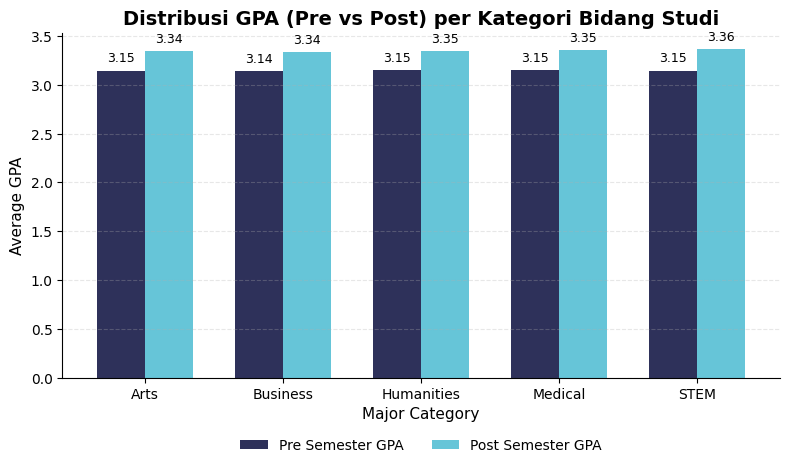

In [ ]:
# Menghitung rata-rata GPA berdasarkan Major_Category
gpa_major = (
    df_clean
    .groupby('Major_Category')[['Pre_Semester_GPA', 'Post_Semester_GPA']]
    .mean()
)

# Membuat visualisasi
ax = gpa_major.plot(
    kind='bar',
    figsize=(8,5),
    color=['#2E315A', '#66C5D8'],
    width=0.7
)

# Judul dan label
plt.title(
    'Distribusi GPA (Pre vs Post) per Kategori Bidang Studi',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Major Category', fontsize=11)
plt.ylabel('Average GPA', fontsize=11)

# Mengatur tampilan sumbu x
plt.xticks(rotation=0)

# Menambahkan label nilai pada setiap bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=4,
        fontsize=9
    )

# Menambahkan grid horizontal
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Menghilangkan border atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Menambahkan legend di bawah tengah
# Menambahkan legend di bawah tengah
plt.legend(
    ['Pre Semester GPA', 'Post Semester GPA'],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.14),   # sebelumnya -0.08
    ncol=2,
    frameon=False,
    fontsize=10                    # diperkecil
)

# Merapikan layout
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Merapikan layout
plt.tight_layout(rect=[0, 0.05, 1, 1])

# Menampilkan grafik
plt.show()

**Insight**:

Hasil visualisasi menunjukkan bahwa seluruh kategori bidang studi mengalami peningkatan rata-rata GPA setelah semester berlangsung. Rata-rata **Post Semester GPA** berada pada kisaran **3,34–3,36**, lebih tinggi dibandingkan **Pre Semester GPA** yang berada pada kisaran **3,14–3,15**.

Peningkatan tersebut relatif konsisten pada seluruh kategori bidang studi, sehingga tidak terdapat perbedaan yang signifikan antar kategori. Selain itu, mahasiswa dari kategori **STEM** memiliki rata-rata **Post Semester GPA** tertinggi, yaitu sekitar **3,36**, sedangkan kategori **Arts** dan **Business** memiliki rata-rata yang sedikit lebih rendah, yaitu sekitar **3,34**.

####**Visualisasi 2 - Hubungan Weekly GenAI Hours dengan Post Semester GPA**



**Tujuan**:

Visualisasi ini bertujuan untuk menganalisis hubungan antara durasi penggunaan Generative AI per minggu (**Weekly_GenAI_Hours**) dengan **Post_Semester_GPA**. Analisis ini dilakukan untuk mengetahui apakah intensitas penggunaan Generative AI memiliki kecenderungan hubungan dengan performa akademik mahasiswa setelah semester berlangsung.

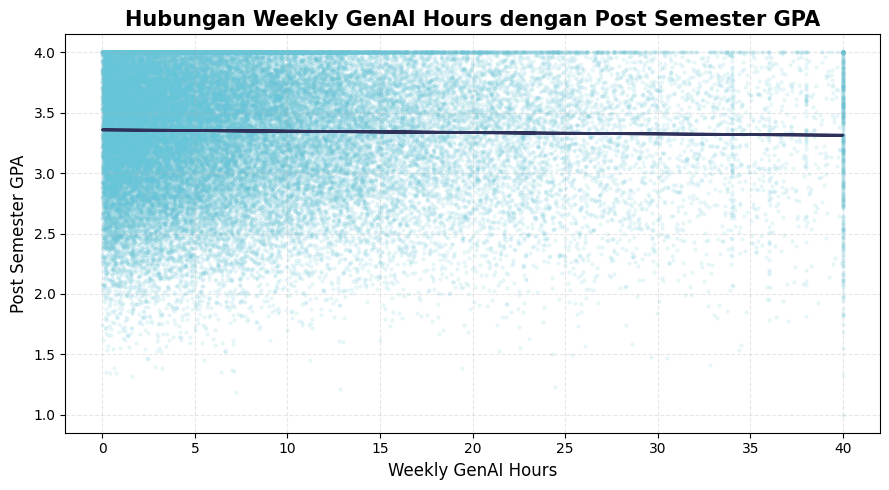

In [ ]:
# Membuat visualisasi hubungan Weekly_GenAI_Hours dengan Post_Semester_GPA

plt.figure(figsize=(9,5))

# Scatter plot
plt.scatter(
    df_clean['Weekly_GenAI_Hours'],
    df_clean['Post_Semester_GPA'],
    color='#66C5D8',
    alpha=0.10,
    s=5
)

# Garis trend (linear)
z = np.polyfit(
    df_clean['Weekly_GenAI_Hours'],
    df_clean['Post_Semester_GPA'],
    1
)

p = np.poly1d(z)

plt.plot(
    df_clean['Weekly_GenAI_Hours'],
    p(df_clean['Weekly_GenAI_Hours']),
    color='#2E315A',
    linewidth=2
)

# Judul dan label
plt.title(
    'Hubungan Weekly GenAI Hours dengan Post Semester GPA',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Weekly GenAI Hours', fontsize=12)
plt.ylabel('Post Semester GPA', fontsize=12)

# Grid
plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# Menampilkan nilai korelasi Pearson

corr = df_clean['Weekly_GenAI_Hours'].corr(df_clean['Post_Semester_GPA'])

print(f'Nilai korelasi Pearson : {corr:.3f}')

Nilai korelasi Pearson : -0.019


**Insight**:

Hasil visualisasi menunjukkan bahwa **tidak terdapat hubungan yang berarti** antara durasi penggunaan Generative AI per minggu (**Weekly_GenAI_Hours**) dengan **Post_Semester_GPA**.

Hal ini didukung oleh nilai **korelasi Pearson sebesar -0,019**, yang menunjukkan **korelasi negatif sangat lemah (hampir tidak ada korelasi)**. Dengan demikian, peningkatan durasi penggunaan Generative AI tidak menunjukkan kecenderungan peningkatan maupun penurunan nilai GPA secara signifikan.

Temuan ini mengindikasikan bahwa performa akademik mahasiswa kemungkinan dipengaruhi oleh faktor lain di luar intensitas penggunaan Generative AI, seperti kebiasaan belajar, kualitas pemanfaatan AI, atau faktor akademik lainnya.

####**Visualisasi 3 - Hubungan Weekly GenAI Hours dengan Skill Retention Score**



**Tujuan**:

Visualisasi ini bertujuan untuk menganalisis hubungan antara durasi penggunaan Generative AI per minggu (**Weekly_GenAI_Hours**) dengan **Skill_Retention_Score**. Analisis ini dilakukan untuk mengetahui apakah intensitas penggunaan Generative AI memiliki kecenderungan hubungan terhadap kemampuan mahasiswa dalam mempertahankan pemahaman dan keterampilan yang telah dipelajari.

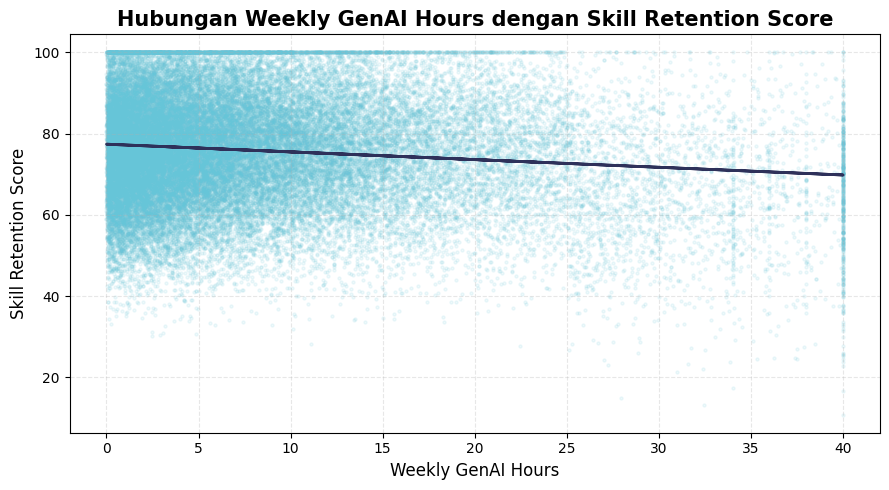

In [ ]:
# Membuat visualisasi hubungan Weekly_GenAI_Hours dengan Skill_Retention_Score

plt.figure(figsize=(9,5))

# Scatter plot
plt.scatter(
    df_clean['Weekly_GenAI_Hours'],
    df_clean['Skill_Retention_Score'],
    color='#66C5D8',
    alpha=0.10,
    s=5
)

# Garis trend
z = np.polyfit(
    df_clean['Weekly_GenAI_Hours'],
    df_clean['Skill_Retention_Score'],
    1
)

p = np.poly1d(z)

plt.plot(
    df_clean['Weekly_GenAI_Hours'],
    p(df_clean['Weekly_GenAI_Hours']),
    color='#2E315A',
    linewidth=2
)

# Judul
plt.title(
    'Hubungan Weekly GenAI Hours dengan Skill Retention Score',
    fontsize=15,
    fontweight='bold'
)

# Label
plt.xlabel('Weekly GenAI Hours', fontsize=12)
plt.ylabel('Skill Retention Score', fontsize=12)

# Grid
plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [ ]:
# Menghitung nilai korelasi Pearson

corr = df_clean['Weekly_GenAI_Hours'].corr(
    df_clean['Skill_Retention_Score']
)

print(f'Nilai korelasi Pearson : {corr:.3f}')

Nilai korelasi Pearson : -0.118


**Insight**:

Hasil visualisasi menunjukkan adanya **korelasi negatif yang lemah** antara durasi penggunaan Generative AI per minggu (**Weekly_GenAI_Hours**) dengan **Skill_Retention_Score**.

Hal ini didukung oleh nilai **korelasi Pearson sebesar -0,118**, yang mengindikasikan bahwa semakin tinggi intensitas penggunaan Generative AI, terdapat kecenderungan penurunan **Skill Retention Score**, meskipun hubungan tersebut relatif lemah.

Temuan ini menunjukkan bahwa penggunaan Generative AI yang lebih intensif tidak selalu diikuti dengan peningkatan kemampuan mahasiswa dalam mempertahankan pemahaman dan keterampilan yang telah dipelajari. Namun, karena nilai korelasi masih rendah, faktor lain di luar penggunaan Generative AI kemungkinan memiliki pengaruh yang lebih besar terhadap kemampuan retensi keterampilan.

####**Visualisasi 4 - Distribusi Burnout Risk Level berdasarkan Institutional Policy**



**Tujuan**:

Visualisasi ini bertujuan untuk membandingkan distribusi tingkat risiko burnout (**Burnout_Risk_Level**) pada setiap kebijakan institusi (**Institutional_Policy**). Analisis ini dilakukan untuk mengetahui apakah terdapat perbedaan pola risiko burnout berdasarkan kebijakan penggunaan Generative AI yang diterapkan oleh institusi.

In [ ]:
# Membuat tabel distribusi Burnout_Risk_Level berdasarkan Institutional_Policy

burnout_policy = pd.crosstab(
    df_clean['Institutional_Policy'],
    df_clean['Burnout_Risk_Level']
)

burnout_policy

Burnout_Risk_Level,High,Low,Medium
Institutional_Policy,,,
Actively_Encouraged,3561,5079,6345
Allowed_With_Citation,6011,8320,10891
Strict_Ban,2912,2970,3905


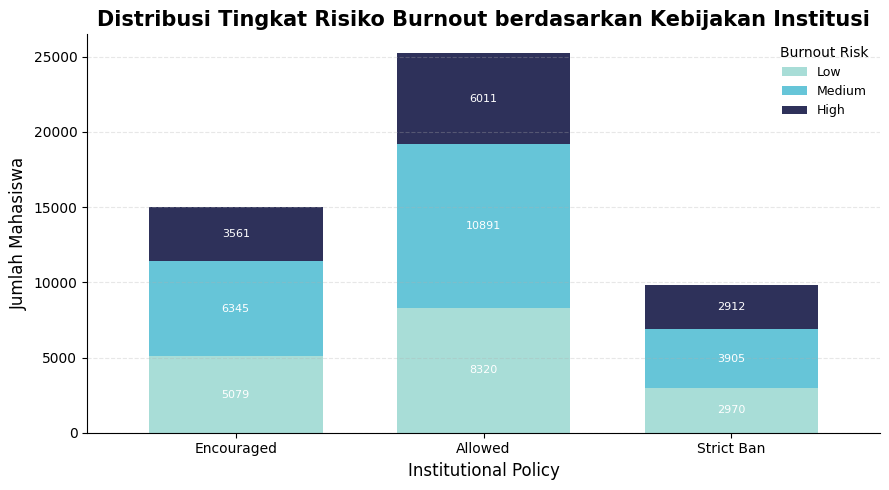

In [ ]:
# Membuat tabel distribusi Burnout_Risk_Level berdasarkan Institutional_Policy

burnout_policy = pd.crosstab(
    df_clean['Institutional_Policy'],
    df_clean['Burnout_Risk_Level']
)

# Mengurutkan level burnout
burnout_policy = burnout_policy[['Low', 'Medium', 'High']]

# Mengganti nama kategori agar lebih ringkas
burnout_policy.index = [
    'Encouraged',
    'Allowed',
    'Strict Ban'
]

# Membuat visualisasi
ax = burnout_policy.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5),
    color=['#A8DDD7', '#66C5D8', '#2E315A'],
    width=0.7
)

# Menambahkan label pada setiap bagian bar
for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=8,
        color='white'
    )

# Judul
plt.title(
    'Distribusi Tingkat Risiko Burnout berdasarkan Kebijakan Institusi',
    fontsize=15,
    fontweight='bold'
)

# Label sumbu
plt.xlabel('Institutional Policy', fontsize=12)
plt.ylabel('Jumlah Mahasiswa', fontsize=12)

# Label sumbu X horizontal
plt.xticks(rotation=0)

# Grid
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Menghilangkan border atas dan kanan
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
plt.legend(
    title='Burnout Risk',
    loc='upper right',
    frameon=False,
    fontsize=9,
    title_fontsize=10
)

# Merapikan layout
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [ ]:
# Menghitung persentase Burnout Risk Level pada setiap Institutional Policy

burnout_percent = pd.crosstab(
    df_clean['Institutional_Policy'],
    df_clean['Burnout_Risk_Level'],
    normalize='index'
) * 100

burnout_percent.round(2)

Burnout_Risk_Level,High,Low,Medium
Institutional_Policy,,,
Actively_Encouraged,23.76,33.89,42.34
Allowed_With_Citation,23.83,32.99,43.18
Strict_Ban,29.75,30.35,39.90


**Insight**:

Visualisasi menunjukkan bahwa pada ketiga kebijakan institusi, mayoritas mahasiswa berada pada kategori **Burnout Risk Level Medium**, dengan proporsi sekitar **40–43%**.

Berdasarkan tabel persentase, kebijakan **Strict Ban** memiliki proporsi mahasiswa dengan **Burnout Risk Level High** paling tinggi (**29,75%**), sedangkan kebijakan **Actively Encouraged** memiliki proporsi **Burnout Risk Level Low** paling tinggi (**33,89%**).

Temuan ini mengindikasikan adanya perbedaan pola distribusi burnout antar kebijakan institusi. Namun, karena analisis ini bersifat deskriptif, hasil tersebut **belum dapat diartikan sebagai hubungan sebab-akibat**. Diperlukan analisis lanjutan untuk mengetahui apakah kebijakan institusi benar-benar memengaruhi tingkat burnout mahasiswa.

####**Visualisasi 5 - Heatmap Korelasi Variabel Numerik**


**Tujuan**:

Visualisasi ini bertujuan untuk mengidentifikasi kekuatan dan arah hubungan antar variabel numerik dalam dataset. Analisis korelasi membantu menemukan variabel yang memiliki hubungan positif maupun negatif sehingga dapat menjadi dasar dalam memperoleh insight awal.

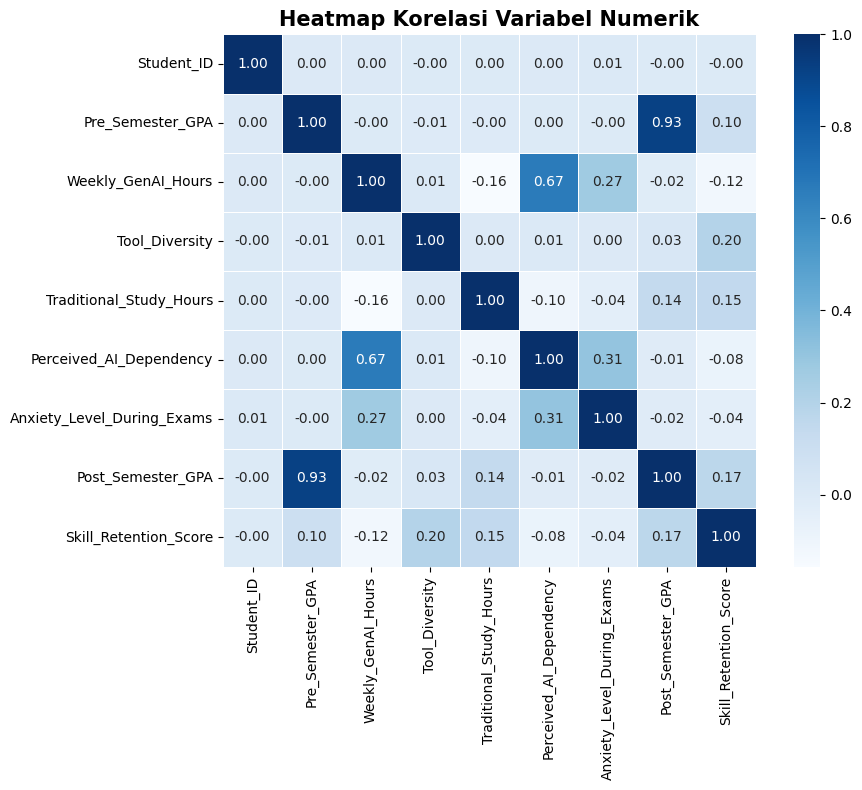

In [ ]:
# Memilih variabel numerik

numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

# Menghitung matriks korelasi

corr_matrix = numeric_df.corr()

# Membuat heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    square=True
)

plt.title(
    'Heatmap Korelasi Variabel Numerik',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

**Insight**:

Berdasarkan heatmap korelasi, sebagian besar variabel memiliki hubungan yang lemah. Namun, terdapat beberapa hubungan yang cukup menonjol.

Variabel **Pre_Semester_GPA** memiliki korelasi positif yang sangat kuat dengan **Post_Semester_GPA** (r = 0,93), menunjukkan bahwa performa akademik sebelum semester merupakan indikator yang kuat terhadap performa akademik setelah semester.

Selain itu, **Weekly_GenAI_Hours** memiliki korelasi positif yang cukup kuat dengan **Perceived_AI_Dependency** (r = 0,67). Hal ini mengindikasikan bahwa semakin tinggi intensitas penggunaan Generative AI, semakin tinggi pula persepsi ketergantungan mahasiswa terhadap AI.

Sementara itu, hubungan antara **Weekly_GenAI_Hours** dengan **Post_Semester_GPA** (r = -0,02) dan **Skill_Retention_Score** (r = -0,12) tergolong sangat lemah hingga lemah. Temuan ini menunjukkan bahwa intensitas penggunaan Generative AI tidak memiliki hubungan yang berarti dengan peningkatan performa akademik maupun retensi keterampilan.

####**Visualisasi 6 - Tren Penggunaan Generative AI berdasarkan Year of Study**



**Tujuan**:

Visualisasi ini bertujuan untuk membandingkan rata-rata durasi penggunaan Generative AI per minggu (**Weekly_GenAI_Hours**) pada setiap jenjang studi (**Year_of_Study**), sehingga dapat diketahui apakah terdapat perbedaan intensitas penggunaan AI antar jenjang mahasiswa.

In [ ]:
# Menghitung rata-rata Weekly_GenAI_Hours berdasarkan Year_of_Study

ai_usage = (
    df_clean
    .groupby('Year_of_Study')['Weekly_GenAI_Hours']
    .mean()
    .reindex(['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'])
)

ai_usage

,Weekly_GenAI_Hours
Year_of_Study,
Freshman,8.445144
Sophomore,8.446249
Junior,8.376758
Senior,8.459251
Graduate,8.405486


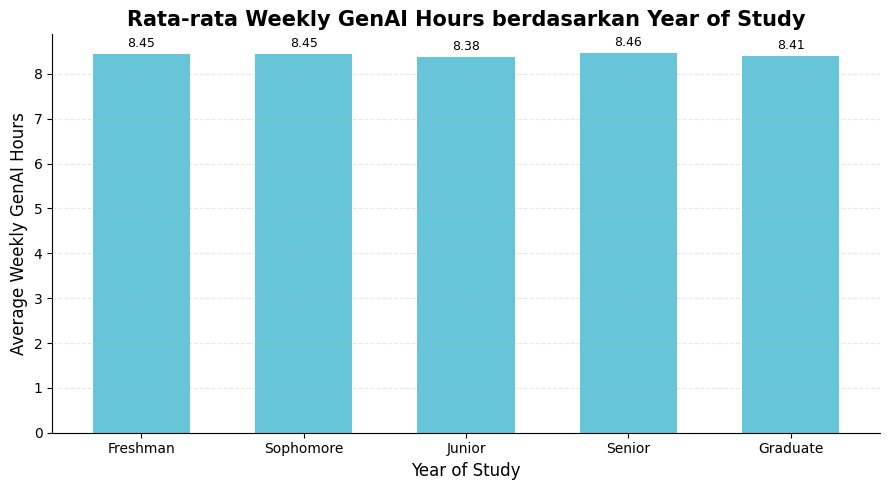

In [ ]:
# Membuat visualisasi rata-rata penggunaan GenAI

ax = ai_usage.plot(
    kind='bar',
    figsize=(9,5),
    color='#66C5D8',
    width=0.6
)

# Menambahkan label nilai
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        fontsize=9,
        padding=3
    )

plt.title(
    'Rata-rata Weekly GenAI Hours berdasarkan Year of Study',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Year of Study', fontsize=12)
plt.ylabel('Average Weekly GenAI Hours', fontsize=12)

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

**Insight**

Visualisasi menunjukkan bahwa rata-rata durasi penggunaan Generative AI per minggu relatif **konsisten pada seluruh jenjang studi**, dengan nilai berkisar antara **8,38 hingga 8,46 jam per minggu**.

Mahasiswa **Senior** memiliki rata-rata penggunaan Generative AI tertinggi (**8,46 jam/minggu**), sedangkan **Junior** memiliki rata-rata terendah (**8,38 jam/minggu**). Namun, perbedaan tersebut sangat kecil sehingga belum menunjukkan adanya pola peningkatan atau penurunan penggunaan AI berdasarkan jenjang studi.

Temuan ini mengindikasikan bahwa pemanfaatan Generative AI telah digunakan secara relatif merata oleh mahasiswa dari berbagai jenjang studi.

####**Visualisasi 7 - Perceived AI Dependency berdasarkan Burnout Risk Level**



**Tujuan**:

Visualisasi ini bertujuan untuk membandingkan distribusi tingkat ketergantungan terhadap Generative AI (**Perceived_AI_Dependency**) pada setiap kategori **Burnout_Risk_Level**. Analisis ini dilakukan untuk mengetahui apakah terdapat perbedaan tingkat ketergantungan AI pada mahasiswa dengan tingkat burnout yang berbeda.

/tmp/ipykernel_51746/4061356845.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


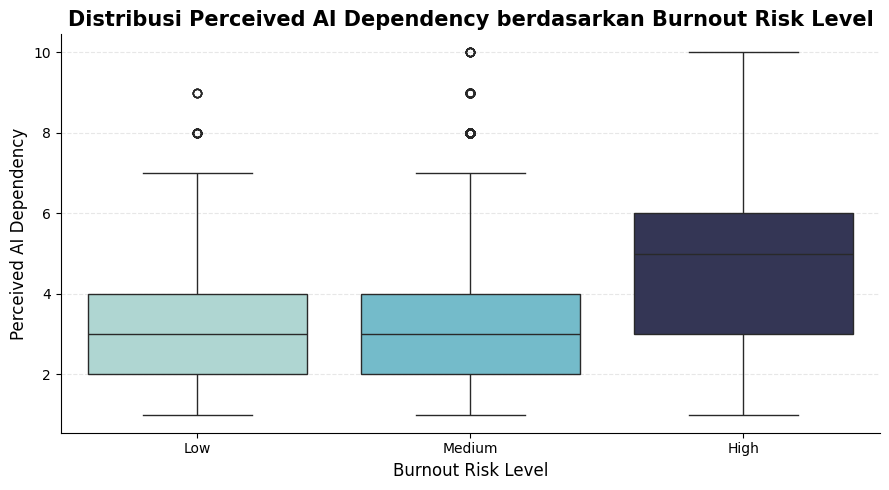

In [ ]:
# Membuat boxplot Perceived_AI_Dependency berdasarkan Burnout_Risk_Level

plt.figure(figsize=(9,5))

sns.boxplot(
    data=df_clean,
    x='Burnout_Risk_Level',
    y='Perceived_AI_Dependency',
    order=['Low', 'Medium', 'High'],
    palette=['#A8DDD7', '#66C5D8', '#2E315A']
)

plt.title(
    'Distribusi Perceived AI Dependency berdasarkan Burnout Risk Level',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Burnout Risk Level', fontsize=12)
plt.ylabel('Perceived AI Dependency', fontsize=12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

sns.despine()

plt.tight_layout()

plt.show()

In [ ]:
# Menampilkan median dan rata-rata setiap kategori

df_clean.groupby('Burnout_Risk_Level')['Perceived_AI_Dependency'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

,mean,median,min,max
Burnout_Risk_Level,,,,
High,4.64,5.0,1.0,10.0
Low,2.82,3.0,1.0,9.0
Medium,3.36,3.0,1.0,10.0


**Insight**:

Visualisasi menunjukkan bahwa mahasiswa dengan **Burnout Risk Level** yang lebih tinggi cenderung memiliki **Perceived AI Dependency** yang lebih tinggi.

Kategori **High Burnout** memiliki nilai rata-rata (**4,64**) dan median (**5**) yang lebih tinggi dibandingkan kategori **Medium** (mean = **3,36**) maupun **Low** (mean = **2,82**).

Selain itu, distribusi pada kategori **High Burnout** juga lebih lebar, menunjukkan variasi tingkat ketergantungan AI yang lebih besar pada kelompok mahasiswa dengan risiko burnout tinggi.

Temuan ini mengindikasikan adanya hubungan positif antara persepsi ketergantungan terhadap Generative AI dan tingkat burnout. Namun, karena analisis ini bersifat deskriptif, hasil tersebut belum dapat diartikan sebagai hubungan sebab-akibat.

##**d. Identifikasi Pola, Anomali, dan Insight Awal**



Berdasarkan hasil Exploratory Data Analysis (EDA), diperoleh beberapa pola, anomali, dan insight yang dapat menjadi dasar dalam memahami hubungan antara penggunaan Generative AI, performa akademik, serta kesejahteraan mahasiswa.

#### **1. Pola Utama**



- Rata-rata **Post Semester GPA** lebih tinggi dibandingkan **Pre Semester GPA** pada seluruh bidang studi, menunjukkan adanya peningkatan performa akademik setelah semester berlangsung.

- Intensitas penggunaan Generative AI relatif konsisten pada seluruh jenjang studi, dengan rata-rata sekitar **8,4 jam per minggu**. Hal ini menunjukkan bahwa pemanfaatan AI telah menjadi bagian dari aktivitas belajar mahasiswa di berbagai tingkat pendidikan.

- Sebagian besar mahasiswa berada pada kategori **Burnout Risk Level Medium**, terlepas dari kebijakan institusi yang diterapkan.

#### **2. Hubungan Antar Variabel**



- Tidak ditemukan hubungan yang berarti antara **Weekly GenAI Hours** dengan **Post Semester GPA** (r = -0,02), sehingga intensitas penggunaan AI tidak berkorelasi dengan peningkatan nilai akademik.

- Hubungan antara **Weekly GenAI Hours** dan **Skill Retention Score** juga tergolong lemah (r = -0,12), sehingga penggunaan AI yang lebih intens belum menunjukkan kaitan dengan peningkatan retensi keterampilan.

- Sebaliknya, terdapat korelasi positif yang cukup kuat antara **Weekly GenAI Hours** dan **Perceived AI Dependency** (r = 0,67). Hal ini menunjukkan bahwa mahasiswa yang lebih sering menggunakan AI cenderung merasa lebih bergantung terhadap teknologi tersebut.

- Mahasiswa dengan **Burnout Risk Level High** memiliki tingkat **Perceived AI Dependency** yang lebih tinggi dibandingkan kategori lainnya.

#### **3. Anomali**



Selama proses validasi data ditemukan beberapa anomali yang telah ditangani sebelum analisis dilakukan, yaitu:

- 2 record dengan format data tidak sesuai sehingga menghasilkan missing values.
- 1 record dengan nilai **Year_of_Study** tidak valid ("123").
- 1 record dengan nilai **Pre_Semester_GPA** di atas batas maksimum (12.249).
- 1 record dengan nilai **Post_Semester_GPA** di atas batas maksimum (10.389).
- 1 record dengan nilai **Tool_Diversity** di luar rentang valid (18).

Seluruh record tersebut dihapus sehingga diperoleh dataset akhir sebanyak **49.994** observasi yang siap dianalisis.

#**F. Menentukan Objek Data**

##**1. Menentukan Variabel Target (Dependent Variable)**


**Tujuan**:

Menentukan variabel target (dependent variable) yang akan digunakan pada setiap jenis analisis sesuai dengan tujuan bisnis dan karakteristik dataset.

**Hasil**:

Berdasarkan tujuan analisis, variabel target yang digunakan adalah sebagai berikut.

| Jenis Analisis | Target Variable | Tujuan |
|----------------|-----------------|--------|
| Regresi | Post_Semester_GPA | Memprediksi performa akademik mahasiswa setelah semester. |
| Klasifikasi | Burnout_Risk_Level | Mengklasifikasikan tingkat risiko burnout mahasiswa. |
| Analisis Korelasi | Skill_Retention_Score | Menganalisis hubungan antara penggunaan Generative AI dengan retensi keterampilan mahasiswa. |

##**2. Menentukan Granularitas Analisis**


**Tujuan**:

Menentukan level analisis data yang akan digunakan agar proses analisis dan agregasi data dilakukan secara konsisten.

**Hasil**:

Granularitas utama pada dataset ini adalah **level individu mahasiswa**, di mana setiap baris data merepresentasikan satu mahasiswa.

Untuk memperoleh insight yang lebih luas, data kemudian dapat diagregasi berdasarkan beberapa variabel, yaitu:

- Major_Category
- Year_of_Study
- Institutional_Policy

Granularitas ini memungkinkan analisis dilakukan baik pada level individu maupun kelompok mahasiswa.

##**3. Menentukan Variabel Predictor**



**Tujuan**:

Memilih variabel independen (predictor) yang relevan berdasarkan domain knowledge dan hasil Exploratory Data Analysis (EDA).

**Hasil**:

Berdasarkan hasil EDA, variabel yang dipilih sebagai predictor adalah:

| Predictor | Alasan |
|-----------|--------|
| Pre_Semester_GPA | Mewakili performa akademik awal mahasiswa. |
| Weekly_GenAI_Hours | Mengukur intensitas penggunaan Generative AI. |
| Traditional_Study_Hours | Menggambarkan kebiasaan belajar konvensional mahasiswa. |
| Prompt_Engineering_Skill | Mewakili kemampuan mahasiswa dalam memanfaatkan AI secara efektif. |
| Tool_Diversity | Menunjukkan variasi tools AI yang digunakan mahasiswa. |
| Perceived_AI_Dependency | Mengukur persepsi ketergantungan terhadap AI. |
| Anxiety_Level_During_Exams | Menggambarkan kondisi psikologis mahasiswa saat ujian. |
| Institutional_Policy | Menggambarkan kebijakan institusi terhadap penggunaan AI. |
| Major_Category | Mewakili bidang studi mahasiswa. |
| Year_of_Study | Mewakili jenjang studi mahasiswa. |

Variabel **Student_ID** tidak digunakan sebagai predictor karena hanya berfungsi sebagai identitas unik mahasiswa.

##**4. Segmentasi Pengguna Generative AI**


**Tujuan**:

Mengelompokkan mahasiswa berdasarkan rata-rata durasi penggunaan Generative AI per minggu agar memudahkan analisis perilaku penggunaan AI.

In [ ]:
# Membuat segmentasi pengguna AI berdasarkan Weekly_GenAI_Hours

df_clean['AI_User_Segment'] = pd.cut(
    df_clean['Weekly_GenAI_Hours'],
    bins=[0, 5, 15, float('inf')],
    labels=['Light User', 'Moderate User', 'Heavy User'],
    include_lowest=True
)

# Menampilkan 5 data pertama
df_clean[['Weekly_GenAI_Hours', 'AI_User_Segment']].head()

,Weekly_GenAI_Hours,AI_User_Segment
0,23.31,Heavy User
1,1.12,Light User
2,21.26,Heavy User
3,1.82,Light User
4,9.29,Moderate User


In [ ]:
# Menampilkan distribusi setiap segmen

segment_summary = (
    df_clean['AI_User_Segment']
    .value_counts()
    .rename_axis('AI_User_Segment')
    .reset_index(name='Frekuensi')
)

segment_summary['Persentase (%)'] = round(
    segment_summary['Frekuensi'] / len(df_clean) * 100,
    2
)

segment_summary

,AI_User_Segment,Frekuensi,Persentase (%)
0,Light User,22591,45.19
1,Moderate User,18870,37.74
2,Heavy User,8533,17.07


**Insight**:

Hasil segmentasi menunjukkan bahwa mayoritas mahasiswa termasuk dalam kategori **Light User** dengan proporsi **45,19%**, diikuti oleh **Moderate User** sebesar **37,74%**, dan **Heavy User** sebesar **17,07%**.

Temuan ini mengindikasikan bahwa sebagian besar mahasiswa menggunakan Generative AI dalam intensitas yang relatif rendah hingga sedang. Sementara itu, hanya sebagian kecil mahasiswa yang menggunakan AI secara intensif (lebih dari 15 jam per minggu).

##**5. Dokumentasi Data Lineage**


**Tujuan**:

Mendokumentasikan alur transformasi data mulai dari data mentah hingga menjadi dataset yang siap digunakan untuk analisis.

**Data Lineage**:

                 Raw Dataset
                      │
                      ▼
               Data Profiling
         (Shape, Info, Missing Value,
            Duplicate, Data Type)
                      │
                      ▼
                Data Cleaning
          • Remove Missing Values
          • Remove Invalid Values
          • Validate Data Types
                      │
                      ▼
               Clean Dataset
                      │
                      ▼
         Exploratory Data Analysis
          • Descriptive Statistics
          • Distribution Analysis
          • Data Visualization
                      │
                      ▼
     Feature Selection & Segmentation
                      │
                      ▼
          Object Data Siap Analisis

# **G. Export Clean Dataset**


**Tujuan**:

Menyimpan dataset hasil proses data cleaning dan validasi agar dapat digunakan pada tahap Business Intelligence Dashboard, analisis lanjutan, maupun sebagai salah satu dokumen yang diserahkan.

In [ ]:
# Menyimpan dataset hasil cleaning ke format CSV

df_clean.to_csv(
    'clean_ai_student_impact_dataset.csv',
    index=False
)

print("Dataset berhasil disimpan sebagai clean_ai_student_impact_dataset.csv")

Dataset berhasil disimpan sebagai clean_ai_student_impact_dataset.csv


In [ ]:
# Menyimpan dataset hasil cleaning ke format Excel

df_clean.to_excel(
    'clean_ai_student_impact_dataset.xlsx',
    index=False
)

print("Dataset berhasil disimpan sebagai clean_ai_student_impact_dataset.xlsx")

Dataset berhasil disimpan sebagai clean_ai_student_impact_dataset.xlsx
